Makine Öğrenmesinde Veri Bölme
 (Train / Dev / Test) Stratejileri
Bu projede, bir veri setinin Eğitim (Train), Geliştirme (Dev/Validation) ve Test setlerine nasıl bölündüğünü ve bu bölme işleminin modelin değerlendirilmesindeki kritik rolünü inceleyeceğiz. Amacımız modelin sadece ezberlemediğini, gerçekten öğrendiğini kanıtlamaktır.

In [2]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

# 1. Veriyi Yükleme
veri = load_breast_cancer()

# Özellikler (X) ve Hedef Değişkeni (y) ayırma
X = pd.DataFrame(veri.data, columns=veri.feature_names)
y = pd.Series(veri.target)

print(f"Toplam Veri Sayısı: {X.shape[0]} satır (örnek), {X.shape[1]} sütun (özellik)")
display(X.head())

Toplam Veri Sayısı: 569 satır (örnek), 30 sütun (özellik)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


2. Veriyi Bölme (Train / Dev / Test Split) ve Ölçeklendirme
Modelimizin veriyi ezberlemesini önlemek ve gerçek dünya performansını ölçmek için veri setimizi üç parçaya ayırıyoruz:

Train (%70): Modelin kalıpları öğreneceği eğitim seti.

Dev / Validation (%15): Modelin ayarlarını yapacağımız ve gelişimini ölçeceğimiz set.

Test (%15): Modelin daha önce hiç görmediği, nihai performansını ölçeceğimiz final sınavı seti.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Önce veriyi %70 Eğitim (Train) ve %30 Geçici (Temp) olarak ikiye bölüyoruz.
# random_state=42 kullanıyoruz ki kodu her çalıştırdığımızda aynı rastgele dağılımı versin (raporlama için önemli).
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# Şimdi o %30'luk Geçici (Temp) veriyi tam ortadan ikiye bölüyoruz: %15 Dev (Validation) ve %15 Test.
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# Yapay Sinir Ağları (TensorFlow) için veriyi standartlaştırıyoruz (Ölçeklendirme)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_dev_scaled = scaler.transform(X_dev)
X_test_scaled = scaler.transform(X_test)

print("Veri seti başarıyla 3 parçaya bölündü ve ölçeklendirildi:")
print(f"Eğitim (Train) Seti: {X_train.shape[0]} satır")
print(f"Geliştirme (Dev/Validation) Seti: {X_dev.shape[0]} satır")
print(f"Test Seti: {X_test.shape[0]} satır")

Veri seti başarıyla 3 parçaya bölündü ve ölçeklendirildi:
Eğitim (Train) Seti: 398 satır
Geliştirme (Dev/Validation) Seti: 85 satır
Test Seti: 86 satır


3. Model Kurulumu ve Eğitimi
Bu aşamada TensorFlow ve Keras kullanarak bir Yapay Sinir Ağı (Neural Network) kuruyoruz.

Kritik Kural: Model sadece Eğitim (Train) verisiyle eğitilir. Geliştirme (Dev) ve Test verileri eğitim aşamasında modele kesinlikle gösterilmez. Eğitilen modelin performansını her üç veri setinde ayrı ayrı test ederek modelin ezber yapıp yapmadığını (overfitting) analiz edeceğiz.

In [5]:
import tensorflow as tf
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Modeli tanımlama (Derin Öğrenme Modeli)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') # İkili sınıflandırma (0 veya 1) için sigmoid kullanılır
])

# Modeli derleme
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 2. Modeli SADECE Eğitim (Train) verisi ile eğitiyoruz
# verbose=0 ile ekrandaki kalabalık eğitim adımlarını gizliyoruz
model.fit(X_train_scaled, y_train, epochs=50, batch_size=16, verbose=0)

# 3. Eğitilmiş modele 3 farklı veri seti için tahminler yaptırıyoruz
# TensorFlow model.predict, 0 ile 1 arasında olasılıklar döndürür.
# Bunları 0.5 eşik değeri ile 0 veya 1 sınıflarına (Kötü Huylu/İyi Huylu) çeviriyoruz.
train_tahmin = (model.predict(X_train_scaled, verbose=0) > 0.5).astype(int).flatten()
dev_tahmin = (model.predict(X_dev_scaled, verbose=0) > 0.5).astype(int).flatten()
test_tahmin = (model.predict(X_test_scaled, verbose=0) > 0.5).astype(int).flatten()

# 4. Başarı oranlarını (Accuracy) hesaplıyoruz
train_basari = accuracy_score(y_train, train_tahmin)
dev_basari = accuracy_score(y_dev, dev_tahmin)
test_basari = accuracy_score(y_test, test_tahmin)

# Sonuçları Yazdırma
print("--- Model Başarı Oranları (Accuracy) ---")
print(f"Eğitim (Train) Seti Başarısı: %{train_basari*100:.2f}  <-- (Modelin bildiği veri, ezber olabilir)")
print(f"Geliştirme (Dev) Seti Başarısı: %{dev_basari*100:.2f}  <-- (Ayar yaptığımız, kontrol verisi)")
print(f"Test Seti Başarısı:       %{test_basari*100:.2f}  <-- (Gerçek dünya performansı, İLK DEFA gördüğü veri)")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


--- Model Başarı Oranları (Accuracy) ---
Eğitim (Train) Seti Başarısı: %99.25  <-- (Modelin bildiği veri, ezber olabilir)
Geliştirme (Dev) Seti Başarısı: %96.47  <-- (Ayar yaptığımız, kontrol verisi)
Test Seti Başarısı:       %98.84  <-- (Gerçek dünya performansı, İLK DEFA gördüğü veri)


4. Sonuçların Görselleştirilmesi (Karmaşıklık Matrisi ve F1-Skoru)
Yapay sinir ağı modelimizin test setindeki başarısını daha detaylı incelemek için Karmaşıklık Matrisi (Confusion Matrix) çizdiriyoruz. Ayrıca sadece Accuracy (Doğruluk) metriğine bağlı kalmamak için Precision, Recall ve F1-Score değerlerini de raporluyoruz.

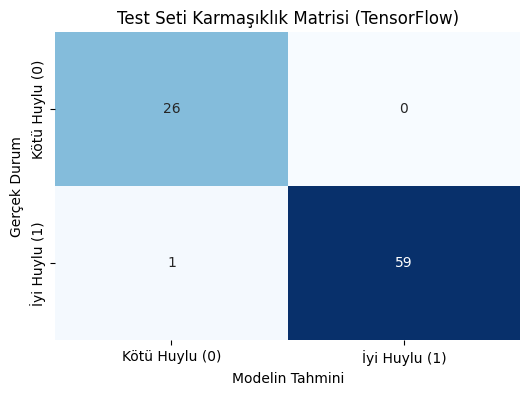


--- Detaylı Sınıflandırma Raporu (Test Seti) ---
                precision    recall  f1-score   support

Kötü Huylu (0)       0.96      1.00      0.98        26
 İyi Huylu (1)       1.00      0.98      0.99        60

      accuracy                           0.99        86
     macro avg       0.98      0.99      0.99        86
  weighted avg       0.99      0.99      0.99        86



In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Karmaşıklık Matrisini (Confusion Matrix) Test verisi için oluşturma
cm = confusion_matrix(y_test, test_tahmin)

# Grafiği çizdirme
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Kötü Huylu (0)", "İyi Huylu (1)"],
            yticklabels=["Kötü Huylu (0)", "İyi Huylu (1)"])
plt.title("Test Seti Karmaşıklık Matrisi (TensorFlow)")
plt.xlabel("Modelin Tahmini")
plt.ylabel("Gerçek Durum")
plt.show()

# F1, Precision ve Recall değerlerini yazdırma
print("\n--- Detaylı Sınıflandırma Raporu (Test Seti) ---")
print(classification_report(y_test, test_tahmin, target_names=["Kötü Huylu (0)", "İyi Huylu (1)"]))